In [ ]:
import numpy as np
import random
import importlib
import s331998_s330519

### Utils

In [110]:
# --- Safe Operations ---

EPS = 1e-6  # small constant to avoid divide-by-zero and overflow


def safe_div(a, b):
    """Safe division: returns a / b if |b| > EPS, otherwise returns 0."""
    try:
        return a / (b if abs(b) > EPS else EPS)
    except Exception:
        return 0.


def safe_log(a):
    """Safe natural log: returns log(|a|) if a is not too close to zero, otherwise returns 0."""
    if abs(a) < EPS:
        return 0.
    return np.log(abs(a))


def safe_exp(a):
    # Clip values to avoid overflow, e.g., limit a's absolute value
    a = np.clip(a, -100, 100)
    return np.exp(a)


def safe_pow(a, b):
    # Clip values to avoid overflow
    a = np.clip(a, -1e6, 1e6)
    b = np.clip(b, -100, 100)
    return np.power(a, b)


# --- Primitive Set of operators ---

# Define a set of functions that can operate elementwise on numpy arrays
primitive_set = {
    'add': { 'func': np.add, 'arity': 2, 'repr': 'np.add' },
    'sub': { 'func': np.subtract, 'arity': 2, 'repr': 'np.subtract' },
    'mul': { 'func': np.multiply, 'arity': 2, 'repr': 'np.multiply' },
    'div': { 'func': np.divide, 'arity': 2, 'repr': 'np.divide' },
    'pow': { 'func': np.pow, 'arity': 2, 'repr': 'np.power' },
    'abs': { 'func': np.abs, 'arity': 1, 'repr': 'np.abs' },
    'sin': { 'func': np.sin, 'arity': 1, 'repr': 'np.sin' },
    'cos': { 'func': np.cos, 'arity': 1, 'repr': 'np.cos' },
    'tan': { 'func': np.tan, 'arity': 1, 'repr': 'np.tan' },
    'exp': { 'func': np.exp, 'arity': 1, 'repr': 'np.exp' },
    'log': { 'func': np.log, 'arity': 1, 'repr': 'np.log' },
}

# We also treat the input variables as terminals. In our case, since the shape of x is (n_vars, n_samples), we refer to them by index, e.g. x[0].
terminal_set = ['x[%d]' % i for i in range(10)]  # allocate up to 10 possible variables, will use as many as needed
# Optionally, add constants as terminals:
constant_pool = [str(round(random.uniform(-100, 100), 2)) for _ in range(100)]

In [7]:
# Disable warnings from numpy about invalid operations
np.seterr(divide='ignore', invalid='ignore', over='ignore', under='ignore')

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

In [ ]:
import re

def update_function_in_file(func_name: str, new_expr: str, filepath="s331998_s330519.py"):
    with open(filepath, 'r') as f:
        code = f.read()

    # Build a regular expression to match the function definition
    func_pattern = rf"def {func_name}\(x: np\.ndarray\) -> np\.ndarray:\n\s+return .+"

    # Replace it with the new function
    new_func = f"def {func_name}(x: np.ndarray) -> np.ndarray:\n    return {new_expr}"
    updated_code = re.sub(func_pattern, new_func, code)

    # Write it back
    with open(filepath, 'w') as f:
        f.write(updated_code)

    print(f"Function `{func_name}` successfully updated.")

### Node Structure

In [10]:
# --- Expression Tree Structure ---

class Node:
    def __init__(self, content, children=None):
        self.content = content  # either a key for primitive_set or a terminal (variable or constant)
        self.children = children if children is not None else []

    def is_terminal(self):
        return len(self.children) == 0

    def evaluate(self, x):
        """Recursively evaluate the expression tree.
           x is expected to be a numpy array where each row is an input variable"""

        # If node is a terminal, interpret it: it's either a float constant or a variable (i.e. x[0])
        if self.is_terminal():
            # If the content is of form 'x[i]', extract the row
            if isinstance(self.content, str) and self.content.startswith('x['):  # Evaluate expression, e.g., "x[0]" returns the first row
                index = int(self.content[2:-1])
                return x[index]
            else:  # Node is a constant string, convert to float and return a numpy array of constant
                return float(self.content) * np.ones(x.shape[1])
        else:
            op = primitive_set[self.content]  # Get the function from the primitive set
            args = [child.evaluate(x) for child in self.children]  # Recursively evaluate children
            return op['func'](*args)  # Apply the operator in a vectorized way

    def __str__(self):
        """Return a string representation of the expression"""
        if self.is_terminal():
            return str(self.content)
        else:
            op_repr = primitive_set[self.content]['repr']
            if primitive_set[self.content]['arity'] == 1:
                return f"{op_repr}({self.children[0]})"
            elif primitive_set[self.content]['arity'] == 2:
                return f"{op_repr}({self.children[0]}, {self.children[1]})"
            else:
                return f"{self.content}(" + ", ".join(str(child) for child in self.children) + ")"

### Evolutionary Algorithm

In [112]:
# --- Generate Random Expression Trees ---

def generate_random_tree(max_depth, current_depth=0, n_vars=2):
    """Generate a random expression tree with a maximum depth"""
    if current_depth >= max_depth or (current_depth > 0 and random.random() < 0.2):
        # Terminal: either a variable (if within dimension) or a constant
        if random.random() < 0.7:
            # Choose one of the available input variables
            var_index = random.randint(0, n_vars - 1)
            return Node(f'x[{var_index}]')
        else:
            # Use a random constant from the pool
            return Node(random.choice(constant_pool))
    else:
        # Choose a random primitive operation from the set
        op_key = random.choice(list(primitive_set.keys()))
        arity = primitive_set[op_key]['arity']
        children = [generate_random_tree(max_depth, current_depth + 1, n_vars) for _ in range(arity)]
        return Node(op_key, children)

In [113]:
# --- Genetic Operators: Crossover and Mutation ---

def mutate(node, max_depth, n_vars):
    """Mutate a tree node by randomly replacing a subtree"""
    if random.random() < 0.1:  # mutation probability at this node level
        return generate_random_tree(max_depth, n_vars=n_vars)
    if not node.is_terminal():
        new_children = [mutate(child, max_depth, n_vars) for child in node.children]
        return Node(node.content, new_children)
    return node


def crossover(node1, node2):
    """Swap a random subtree between node1 and node2"""
    if random.random() < 0.1:
        return node2
    if not node1.is_terminal() and not node2.is_terminal():
        new_children = []
        for child in node1.children:
            # With a certain probability, replace this child with a randomly chosen subtree from node2
            if random.random() < 0.5:
                new_children.append(random.choice(flatten_tree(node2)))
            else:
                new_children.append(child)
        return Node(node1.content, new_children)
    return node1


def flatten_tree(node):
    """Return a list of all nodes in the tree."""
    nodes = [node]
    if not node.is_terminal():
        for child in node.children:
            nodes.extend(flatten_tree(child))
    return nodes

In [114]:
# --- Fitness Function ---

def fitness(individual: Node, x: np.ndarray, y: np.ndarray):
    """Compute the Mean Squared Error (MSE) of an individual's expression on the data.
    The MSE measures the error between the real prediction y and the value predicted by the expression
    (calculated evaluating the tree with root "individual")
    """
    try:
        y_pred = individual.evaluate(x)
        # Ensure y_pred has the same shape as y.
        if y_pred.shape != y.shape:
            return np.inf
        mse = np.mean((y - y_pred) ** 2)
        if np.isnan(mse):
            return np.inf
        return mse
    except Exception:
        return np.inf

In [115]:
# --- Evolutionary Algorithm ---

def genetic_programming(x: np.ndarray, y: np.ndarray, n_vars: int, population_size=100, generations=50, max_depth=5, threshold=1e-5):
    # Create an initial population of random trees
    population = [generate_random_tree(max_depth, n_vars=n_vars) for _ in range(population_size)]
    best_individual = None
    best_fitness = np.inf

    for gen in range(generations):
        fitness_values = [fitness(ind, x, y) for ind in population]  # Evaluate fitness for each individual

        # Check if we have a solution that is good enough (early stopping)
        if min(fitness_values) < threshold:
            best_fitness = min(fitness_values)
            best_individual = population[fitness_values.index(best_fitness)]
            print(f"Early stopping at generation {gen}: best fitness = {best_fitness}")
            break

        # Save the best so far
        for ind, fit in zip(population, fitness_values):
            if fit < best_fitness:
                best_fitness = fit
                best_individual = ind

        if gen % 100 == 0 or gen == generations - 1:
            print(f"Generation {gen}: best fitness = {best_fitness}")

        # Create a new population
        new_population = []
        for _ in range(population_size):
            # Tournament selection: choose two individuals and pick the better one
            candidates = random.sample(list(zip(population, fitness_values)), 3)
            parent = min(candidates, key=lambda item: item[1])[0]

            # Clone and mutate
            child = mutate(parent, max_depth, n_vars)

            # Optionally, perform crossover with another individual
            mate = random.choice(population)
            child = crossover(child, mate)
            new_population.append(child)
        population = new_population

    print("Best expression found:")
    print(best_individual)
    return best_individual

### Plots

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # This import registers the 3D projection


def plot_true_vs_predicted(y_true: np.ndarray, y_pred: np.ndarray):
    """ Generates a scatter plot of true vs predicted values """
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.5, c='blue', edgecolors='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title('Predicted vs. True Values')
    plt.grid(True)
    plt.show()


def plot_3d_comparison(x: np.ndarray, y_true: np.ndarray, y_pred: np.ndarray):
    """ Generates 3D plots for the data.
    
    If the input x has two rows (variables), two 3D scatter plots are shown:
       - Left: True values
       - Right: Predicted values
       
    If x has more than two variables, the first two dimensions are used as the plane and
    the output values (y_true or y_pred) are shown in the third axis.
    """
    n_vars, n_samples = x.shape

    # When there are two input dimensions (n_vars == 2)
    if n_vars == 2:
        fig = plt.figure(figsize=(14, 6))

        # Plot True Values
        ax1 = fig.add_subplot(121, projection='3d')
        sc1 = ax1.scatter(x[0], x[1], y_true, c=y_true, cmap='viridis', alpha=0.8)
        ax1.set_title('True Values')
        ax1.set_xlabel('x[0]')
        ax1.set_ylabel('x[1]')
        ax1.set_zlabel('y')
        fig.colorbar(sc1, ax=ax1, shrink=0.5, aspect=10)

        # Plot Predicted Values
        ax2 = fig.add_subplot(122, projection='3d')
        sc2 = ax2.scatter(x[0], x[1], y_pred, c=y_pred, cmap='viridis', alpha=0.8)
        ax2.set_title('Predicted Values')
        ax2.set_xlabel('x[0]')
        ax2.set_ylabel('x[1]')
        ax2.set_zlabel('y')
        fig.colorbar(sc2, ax=ax2, shrink=0.5, aspect=10)

        plt.tight_layout()
        plt.show()

    # When there are more than two input dimensions
    elif n_vars >= 3:
        # We will use the first two dimensions for x and y axes, and then use the output values as the third axis
        fig = plt.figure(figsize=(14, 6))

        # True Values 3D scatter
        ax1 = fig.add_subplot(121, projection='3d')
        sc1 = ax1.scatter(x[0], x[1], y_true, c=y_true, cmap='coolwarm', alpha=0.8)
        ax1.set_title('True Values (using first two input dims)')
        ax1.set_xlabel('x[0]')
        ax1.set_ylabel('x[1]')
        ax1.set_zlabel('y')
        fig.colorbar(sc1, ax=ax1, shrink=0.5, aspect=10)

        # Predicted Values 3D scatter
        ax2 = fig.add_subplot(122, projection='3d')
        sc2 = ax2.scatter(x[0], x[1], y_pred, c=y_pred, cmap='coolwarm', alpha=0.8)
        ax2.set_title('Predicted Values (using first two input dims)')
        ax2.set_xlabel('x[0]')
        ax2.set_ylabel('x[1]')
        ax2.set_zlabel('y')
        fig.colorbar(sc2, ax=ax2, shrink=0.5, aspect=10)

        plt.tight_layout()
        plt.show()

    else:  # Lower-dimensional case: only one input variable
        plt.figure(figsize=(8, 5))
        plt.scatter(x[0], y_true, c='blue', label='True Values', alpha=0.6, marker='o')
        plt.scatter(x[0], y_pred, c='red', label='Predicted Values', alpha=0.6, marker='x')
        plt.xlabel('x[0]')
        plt.ylabel('y')
        plt.title('Lower-Dimensional Data: True vs. Predicted Values')
        plt.legend()
        plt.grid(True)
        plt.show()

## Main Routine

In [116]:
# --- Main Routine for Each Dataset ---

def run_symbolic_regression(dataset_path: str, population_size=100, generations=500, max_depth=5):
    data = np.load(dataset_path)
    x = data['x']  # x shape: (n_vars, n_samples)
    y = data['y']  # y shape: (n_samples,)
    n_vars = x.shape[0]
    best_tree = genetic_programming(x, y, n_vars, population_size, generations, max_depth)
    # Convert the best tree to a Python expression string
    expression_str = str(best_tree)
    return expression_str

### Function f1

In [62]:
# --- Generate Function f1 ---
dataset_file = "data/problem_1.npz"
print(f"Processing dataset 1 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=100, generations=500, max_depth=5)

print("\nGenerated function f1:")
print("def f1(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 1 from data/problem_1.npz...
Early stopping at generation 0: best fitness = 3.921193366772412e-34
Best expression found:
np.sin(x[0])

Generated function f1:
def f1(x: np.ndarray) -> np.ndarray:
    return np.sin(x[0])


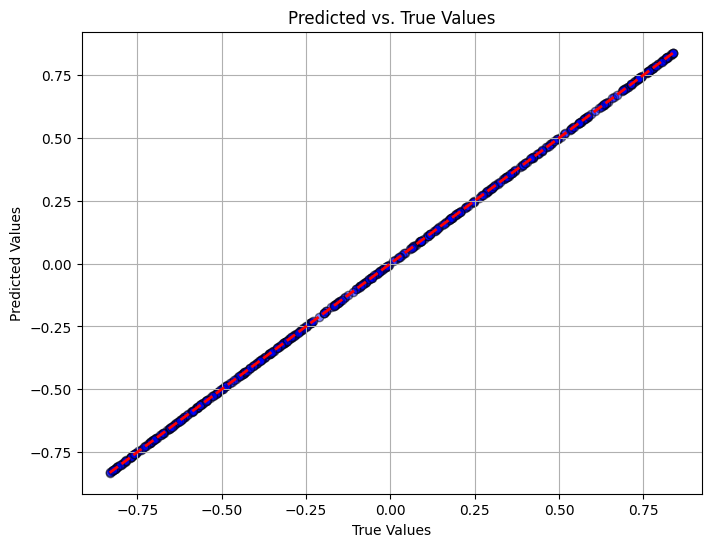

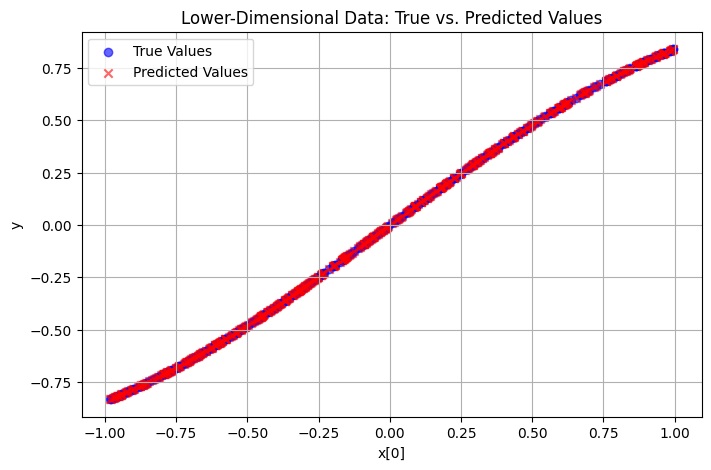

In [ ]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_1.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f1(x.copy()) # Compute predictions using the imported f1 function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f2

In [117]:
# --- Generate Function f2 ---
dataset_file = "data/problem_2.npz"
print(f"Processing dataset 2 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=300, generations=1500, max_depth=10)

print("\nGenerated function f2:")
print("def f2(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 2 from data/problem_2.npz...
Generation 0: best fitness = 29616716131176.12
Generation 100: best fitness = 21806998037122.363
Generation 200: best fitness = 21806998037122.363
Generation 300: best fitness = 19789560836183.637
Generation 400: best fitness = 19656905792608.574
Generation 500: best fitness = 19021067732061.934
Generation 600: best fitness = 19021067732061.934
Generation 700: best fitness = 19021067732061.934
Generation 800: best fitness = 19021067732061.934
Generation 900: best fitness = 19021067732061.934
Generation 1000: best fitness = 19021067732061.934
Generation 1100: best fitness = 19021067732061.934
Generation 1200: best fitness = 19021067732061.934
Generation 1300: best fitness = 19021067732061.934
Generation 1400: best fitness = 19021067732061.934
Generation 1499: best fitness = 19021067732061.934
Best expression found:
np.multiply(np.multiply(73.05, np.multiply(np.abs(23.51), 7.13)), np.multiply(x[0], 93.4))

Generated function f2:
def f2(x: n

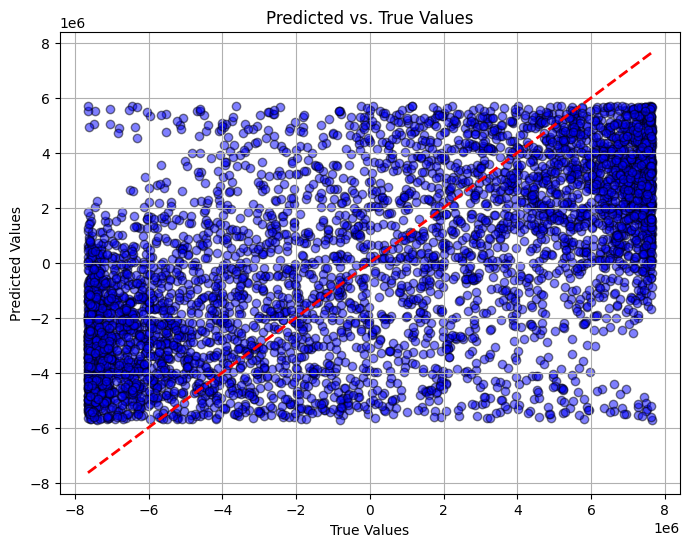

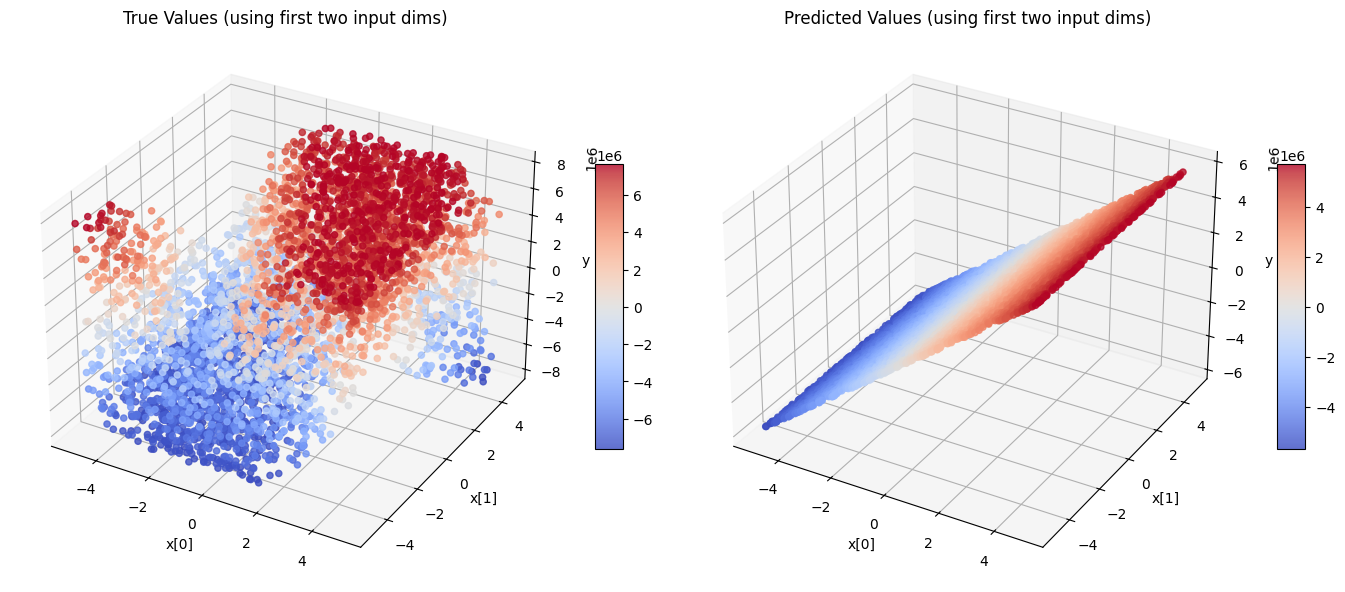

In [120]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_2.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f2(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f3

In [19]:
# --- Generate Function f3 ---
dataset_file = "data/problem_3.npz"
print(f"Processing dataset 3 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=500, generations=500, max_depth=10)

print("Generated function f3:")
print("def f3(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 3 from data/problem_3.npz...
Generation 0: best fitness = 2561.5352489741176
Generation 100: best fitness = 2561.5352489741176
Generation 200: best fitness = 2561.5352489741176
Generation 300: best fitness = 2561.5352489741176
Generation 400: best fitness = 2561.5352489741176
Generation 499: best fitness = 2561.53524884658
Best expression found:
np.add(np.tan(np.tan(0.99)), np.sin(np.abs(x[2], x[2])))
Generated function f3:
def f3(x: np.ndarray) -> np.ndarray:
    return np.add(np.tan(np.tan(0.99)), np.sin(np.abs(x[2], x[2])))


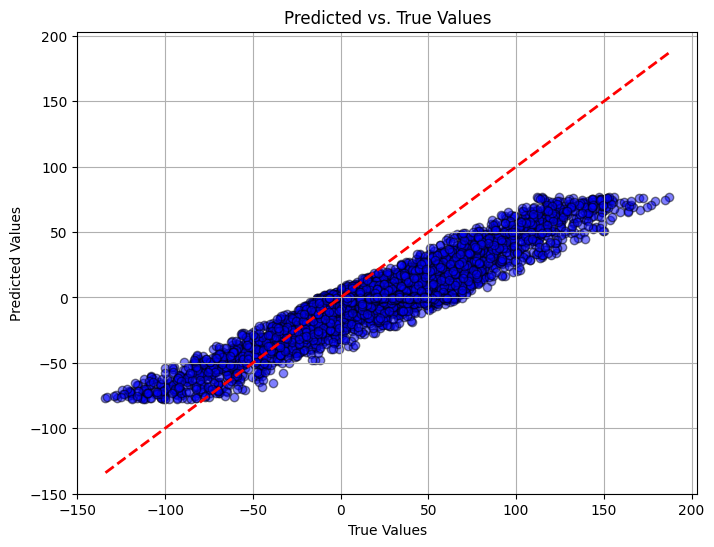

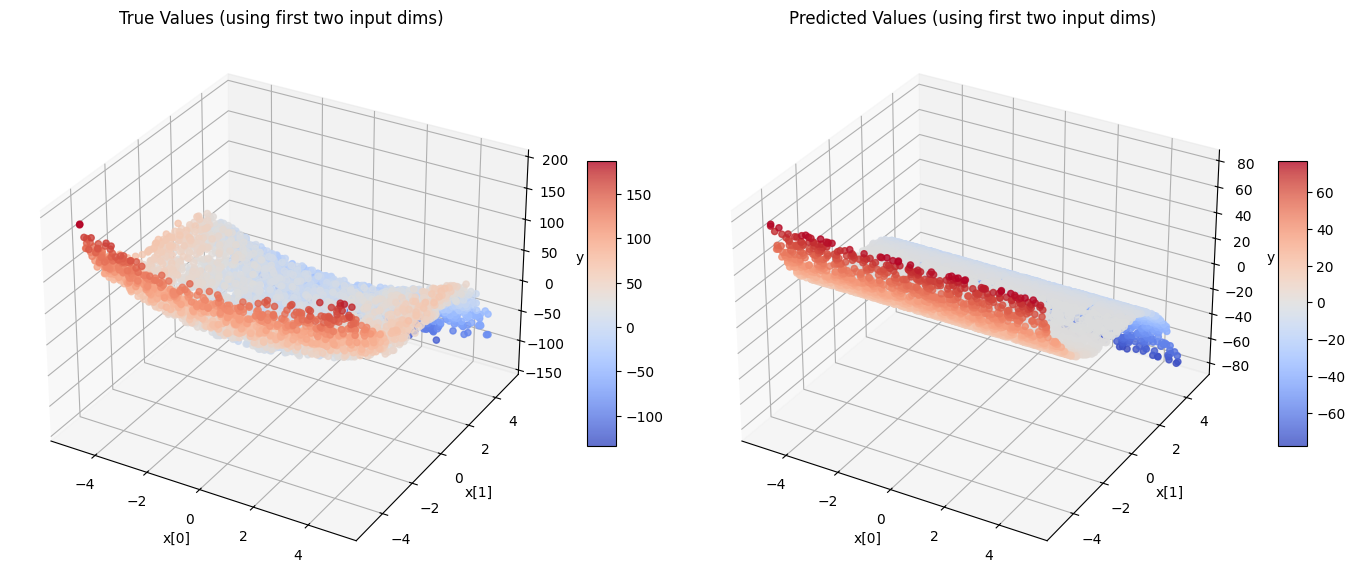

In [ ]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_3.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f3(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f4

In [58]:
# --- Generate Function f4 ---
dataset_file = "data/problem_4.npz"
print(f"Processing dataset 4 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=100, generations=500, max_depth=5)

print("Generated function f4:")
print("def f4(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 4 from data/problem_4.npz...
Generation 0: best fitness = 21.8486817557889
Generation 100: best fitness = 21.622001615115643
Generation 200: best fitness = 21.622001615115643
Generation 300: best fitness = 21.622001615115643
Generation 400: best fitness = 21.622001615115643
Generation 499: best fitness = 21.622001615115643
Best expression found:
np.exp(np.multiply(x[0], 0.99))
Generated function f4:
def f4(x: np.ndarray) -> np.ndarray:
    return np.exp(np.multiply(x[0], 0.99))


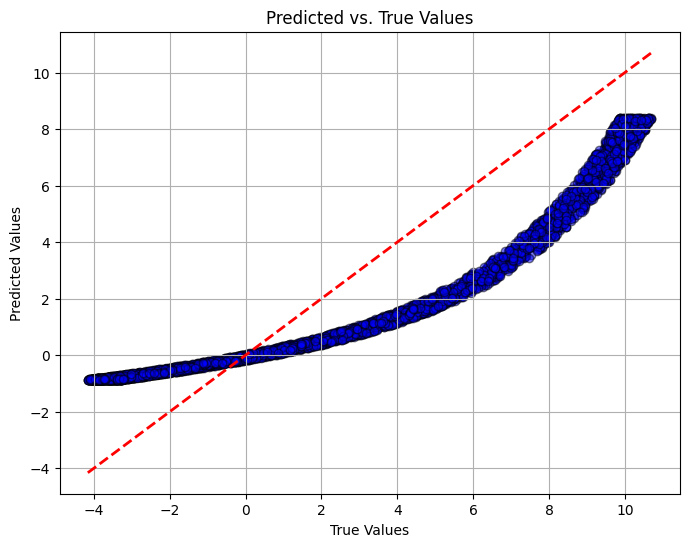

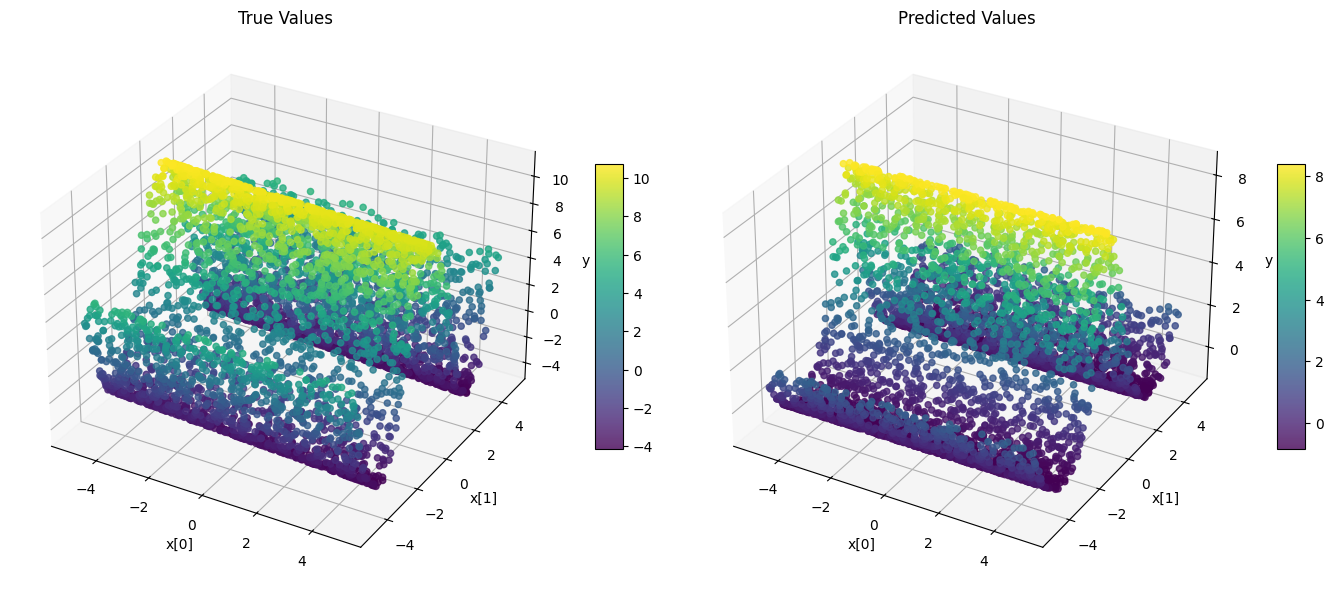

In [ ]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_4.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f4(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f5

In [47]:
# --- Generate Function f5 ---
dataset_file = "data/problem_5.npz"
print(f"Processing dataset 5 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=100, generations=500, max_depth=5)

print("Generated function f5:")
print("def f5(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 5 from data/problem_5.npz...
Early stopping at generation 0: best fitness = 5.572810232617333e-18
Best expression found:
np.multiply(x[1], np.multiply(np.add(np.subtract(x[0], x[1]), np.multiply(np.subtract(x[0], x[1]), np.log(x[0]))), np.log(x[0])))
Generated function f5:
def f5(x: np.ndarray) -> np.ndarray:
    return np.multiply(x[1], np.multiply(np.add(np.subtract(x[0], x[1]), np.multiply(np.subtract(x[0], x[1]), np.log(x[0]))), np.log(x[0])))


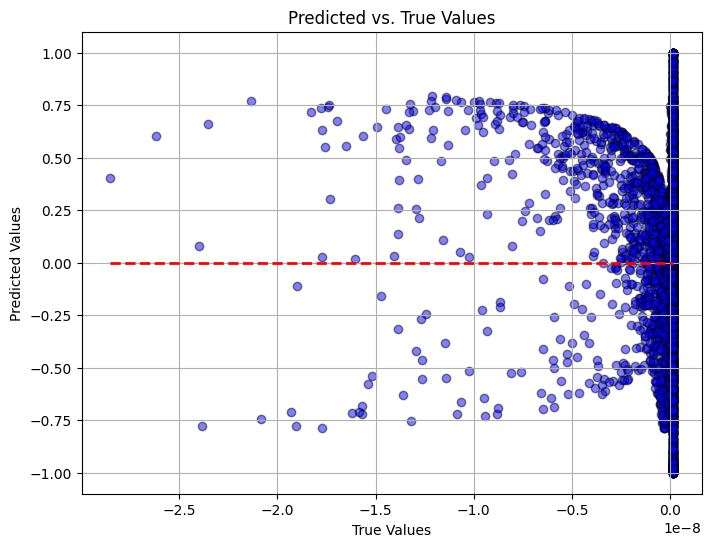

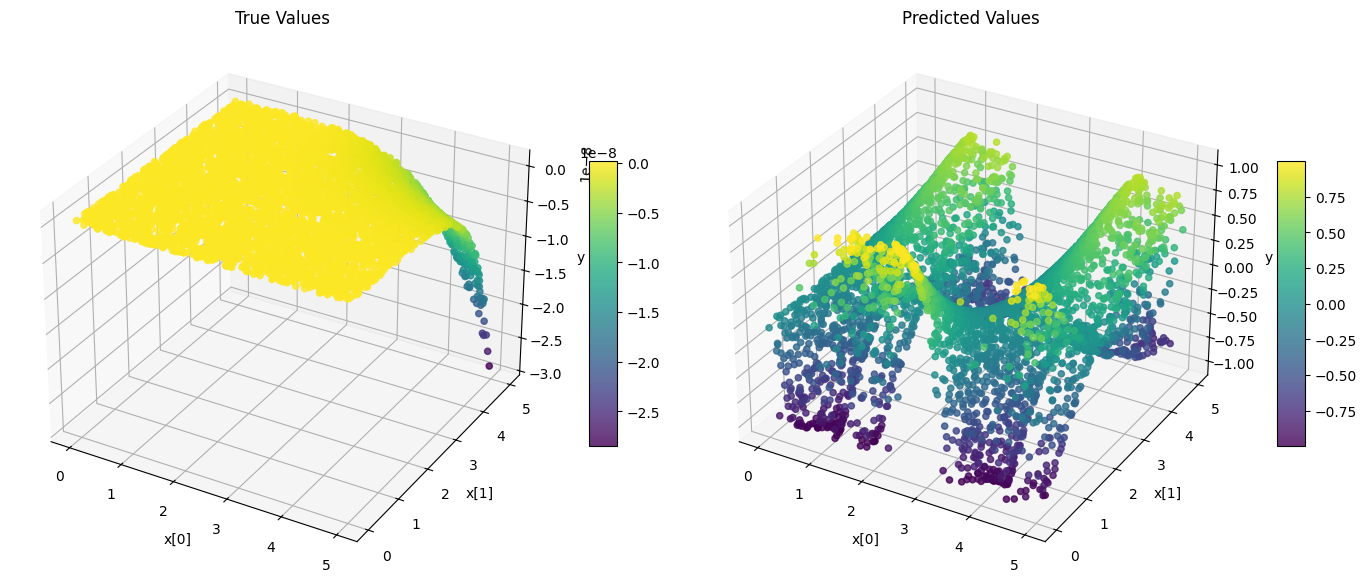

In [ ]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_5.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f5(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f6

In [91]:
# --- Generate Function f6 ---
dataset_file = "data/problem_6.npz"
print(f"Processing dataset 6 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=100, generations=1000, max_depth=8)

print("Generated function f6:")
print("def f6(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 6 from data/problem_6.npz...
Generation 0: best fitness = 18.114399140392955
Generation 100: best fitness = 13.649341108704428
Generation 200: best fitness = 13.649341108704428
Generation 300: best fitness = 13.649341108704428
Generation 400: best fitness = 13.649341108704428
Generation 500: best fitness = 13.649341108704428
Generation 600: best fitness = 13.649341108704428
Generation 700: best fitness = 13.649341108704428
Generation 800: best fitness = 13.649341108704428
Generation 900: best fitness = 13.649341108704428
Generation 999: best fitness = 13.649341108704428
Best expression found:
np.add(-3.49, np.subtract(x[1], np.tan(x[1])))
Generated function f6:
def f6(x: np.ndarray) -> np.ndarray:
    return np.add(-3.49, np.subtract(x[1], np.tan(x[1])))


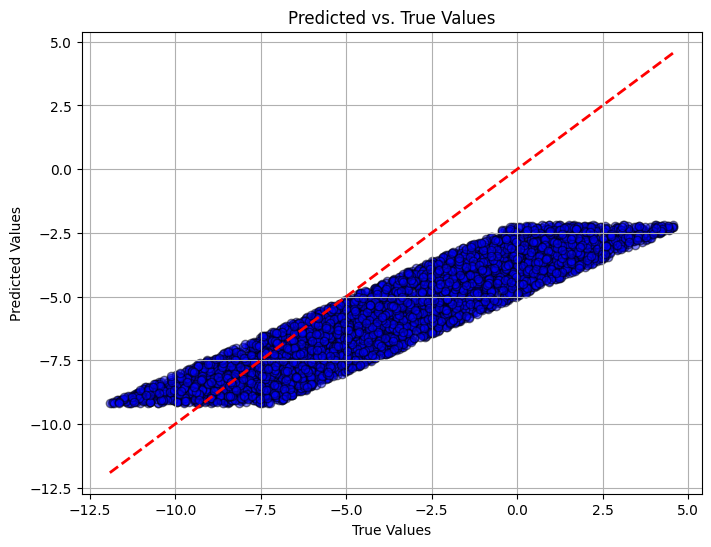

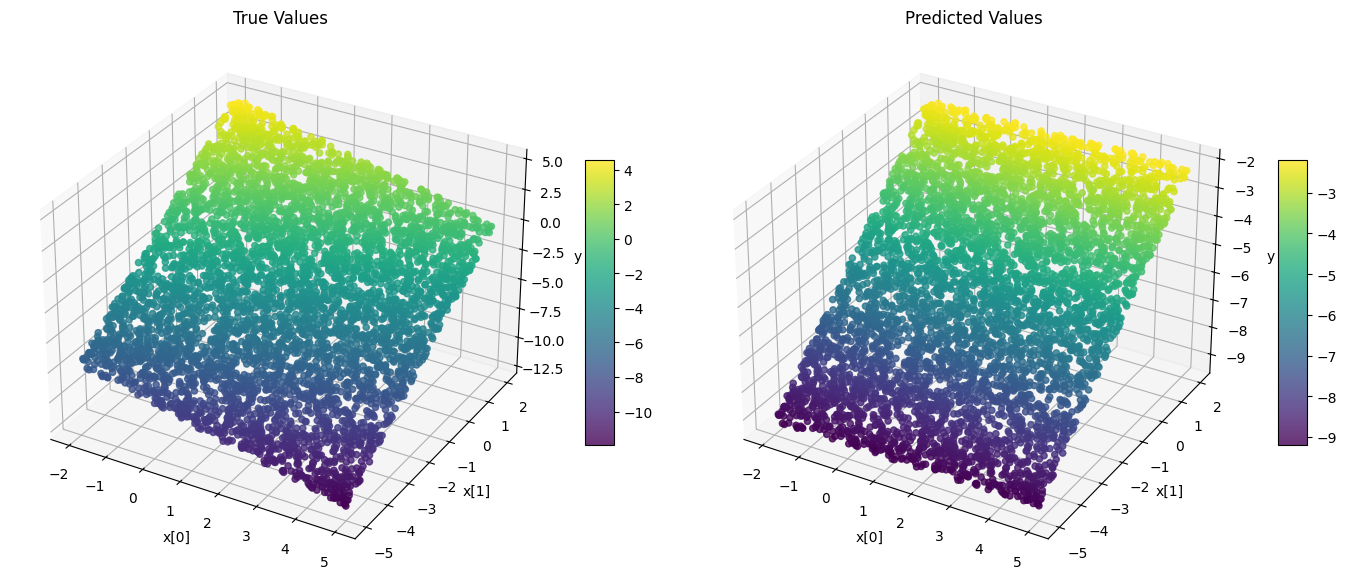

In [93]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_6.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f6(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f7

In [51]:
# --- Generate Function f7 ---
dataset_file = "data/problem_7.npz"
print(f"Processing dataset 7 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=100, generations=500, max_depth=5)

print("Generated function f7:")
print("def f7(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 7 from data/problem_7.npz...
Generation 0: best fitness = 724.4674480652806
Generation 100: best fitness = 711.1563343205631
Generation 200: best fitness = 711.1563343205631
Generation 300: best fitness = 711.1563343205631
Generation 400: best fitness = 711.1563343205631
Generation 499: best fitness = 711.1561677668936
Best expression found:
np.add(np.log(np.divide(np.subtract(np.tan(x[1]), np.subtract(-1.33, x[0])), 0.62)), np.tan(-4.84))
Generated function f7:
def f7(x: np.ndarray) -> np.ndarray:
    return np.add(np.log(np.divide(np.subtract(np.tan(x[1]), np.subtract(-1.33, x[0])), 0.62)), np.tan(-4.84))


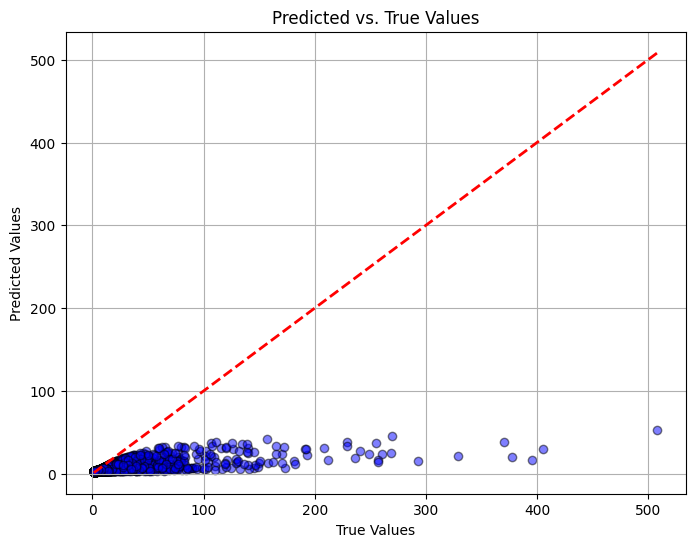

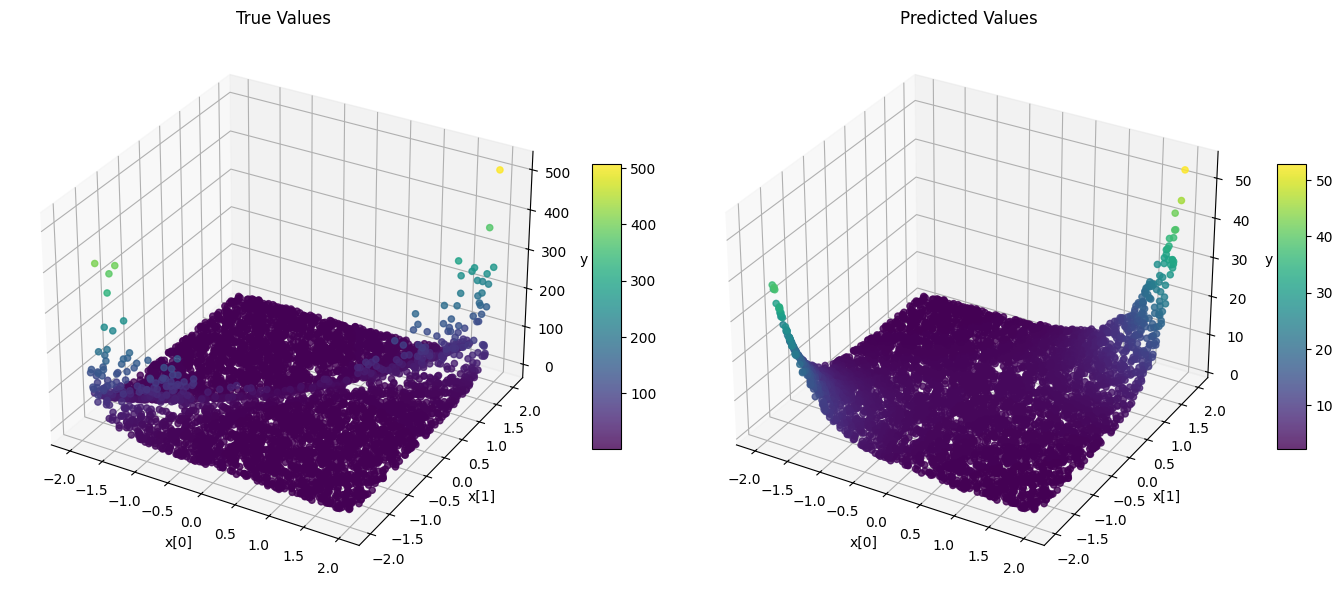

In [81]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_7.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f7(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred)  # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f8

In [53]:
# --- Generate Function f8 ---
dataset_file = "data/problem_8.npz"
print(f"Processing dataset 8 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=100, generations=500, max_depth=5)

print("Generated function f8:")
print("def f8(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 8 from data/problem_8.npz...
Generation 0: best fitness = 23005539.796351627
Generation 100: best fitness = 22706855.479548253
Generation 200: best fitness = 22706545.1246827
Generation 300: best fitness = 22706545.1246827
Generation 400: best fitness = 22706545.1246827
Generation 499: best fitness = 22705941.856815245
Best expression found:
np.subtract(np.add(np.subtract(np.exp(np.cos(x[5])), np.exp(np.multiply(x[3], x[2]))), np.divide(x[0], x[4])), -4.84)
Generated function f8:
def f8(x: np.ndarray) -> np.ndarray:
    return np.subtract(np.add(np.subtract(np.exp(np.cos(x[5])), np.exp(np.multiply(x[3], x[2]))), np.divide(x[0], x[4])), -4.84)


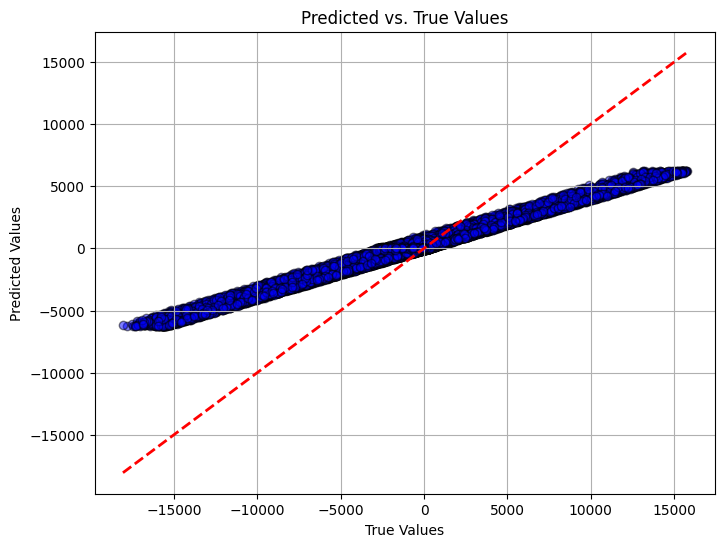

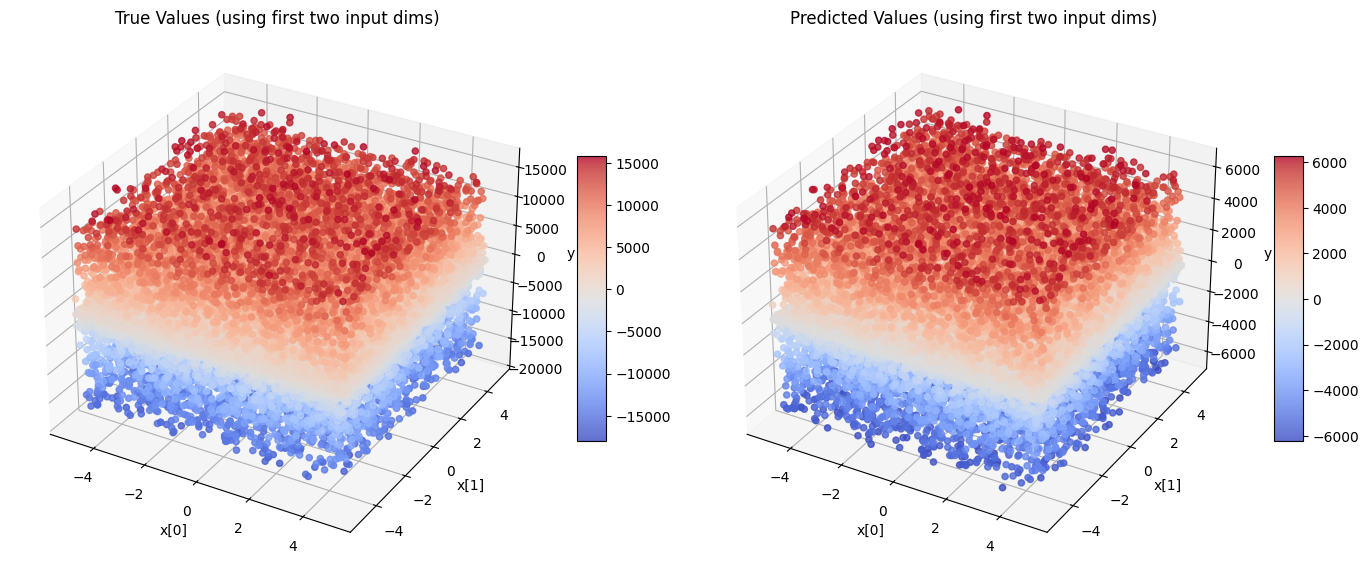

In [ ]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_8.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f8(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots